#  Panier Moyen et Market Basket Analysis
**Objectif :** Analyser la composition des commandes pour augmenter la valeur du panier client.

### Deux axes d'analyse :
1. **Le Panier Moyen (Average Order Value - AOV)** : Comprendre la distribution du montant dépensé par commande pour définir des objectifs de croissance.
2. **Market Basket Analysis (MBA)** : Identifier les associations de produits (quels articles sont achetés ensemble) afin de créer des offres groupées (bundles).

**Impact Business :** Optimisation du merchandising web et augmentation du chiffre d'affaires par client.

Calcul du panier moyen...


c:\Users\salma\classicmodels-analysis\src\analysis\connection.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


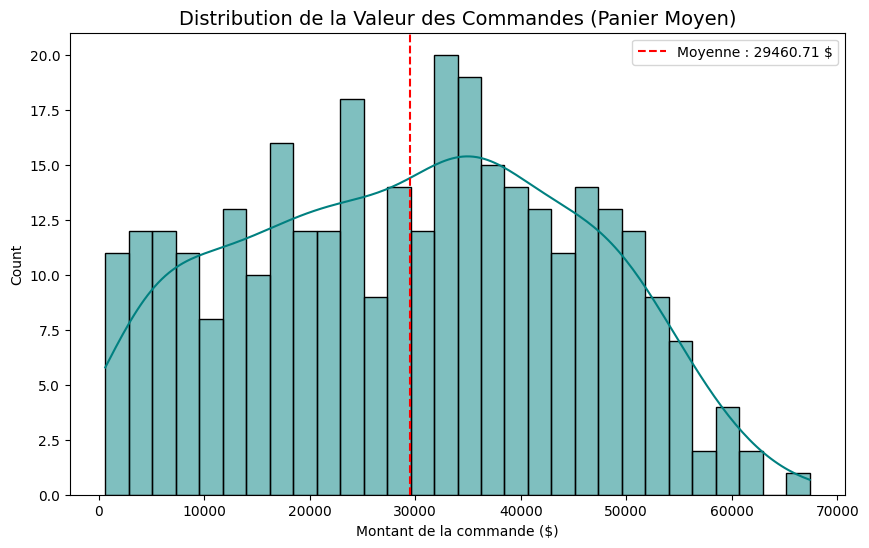

Analyse des associations de produits...


c:\Users\salma\classicmodels-analysis\src\analysis\connection.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


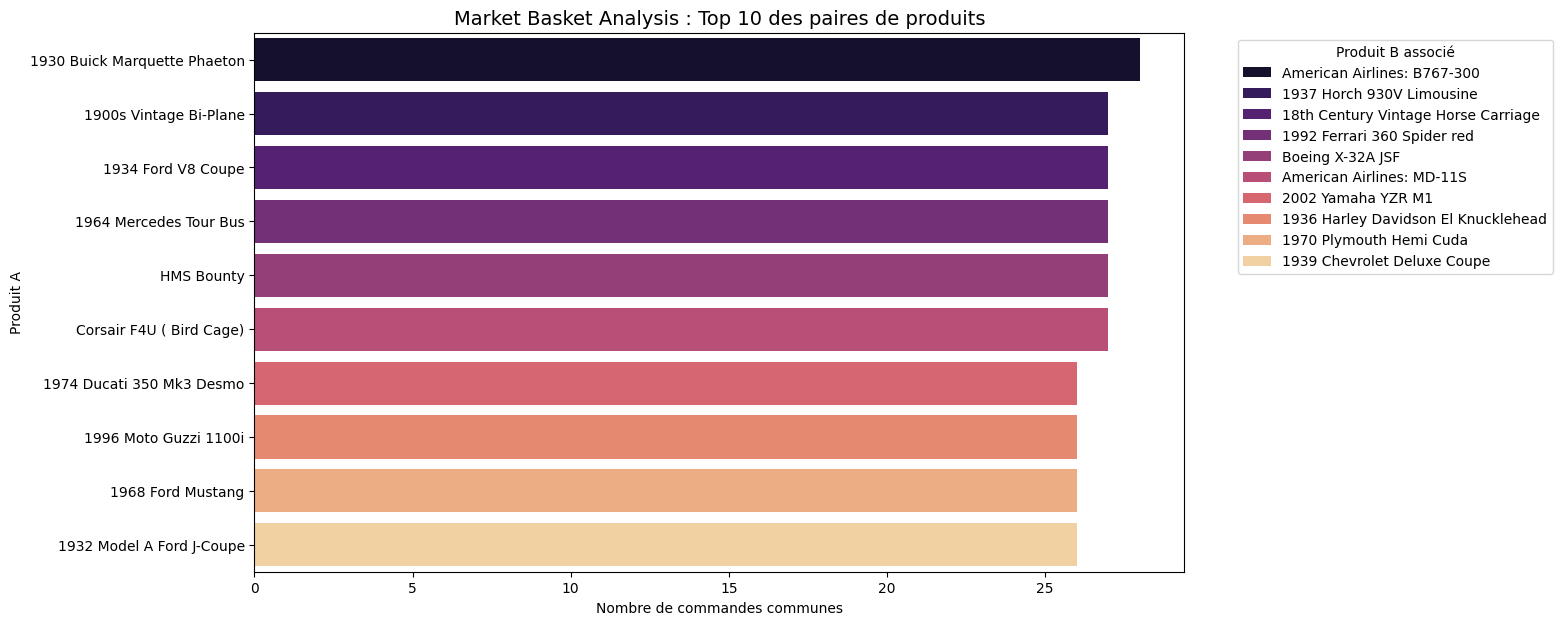

Panier moyen global : 29460.71 $


In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CONFIGURATION DU CHEMIN
sys.path.append(os.path.abspath(os.path.join('..')))
from src.analysis.connection import get_db_data 

# 2. ANALYSE 1 : DISTRIBUTION DU PANIER MOYEN (AOV)
print("Calcul du panier moyen...")
query_aov = """
    SELECT 
        orderNumber, 
        SUM(quantityOrdered * priceEach) AS total_order_value
    FROM orderdetails
    GROUP BY orderNumber
"""
df_aov = get_db_data(query_aov)
avg_basket = df_aov['total_order_value'].mean()

# Visualisation AOV
plt.figure(figsize=(10, 6))
sns.histplot(df_aov['total_order_value'], bins=30, kde=True, color='teal')
plt.axvline(avg_basket, color='red', linestyle='--', label=f'Moyenne : {avg_basket:.2f} $')
plt.title('Distribution de la Valeur des Commandes (Panier Moyen)', fontsize=14)
plt.xlabel('Montant de la commande ($)')
plt.legend()
plt.savefig(os.path.join('..', 'visualisations', 'average_basket_distribution.png'), bbox_inches='tight')
plt.show()

# 3. ANALYSE 2 : MARKET BASKET ANALYSIS (Top paires de produits)
print("Analyse des associations de produits...")
query_basket = """
    SELECT 
        p1.productName AS product_A, 
        p2.productName AS product_B, 
        COUNT(*) AS times_bought_together
    FROM orderdetails od1
    JOIN orderdetails od2 ON od1.orderNumber = od2.orderNumber 
        AND od1.productCode < od2.productCode
    JOIN products p1 ON od1.productCode = p1.productCode
    JOIN products p2 ON od2.productCode = p2.productCode
    GROUP BY product_A, product_B
    ORDER BY times_bought_together DESC
    LIMIT 10;
"""
df_basket = get_db_data(query_basket)

# Visualisation MBA
plt.figure(figsize=(12, 7))
sns.barplot(data=df_basket, x='times_bought_together', y='product_A', hue='product_B', palette='magma')
plt.title('Market Basket Analysis : Top 10 des paires de produits', fontsize=14)
plt.xlabel('Nombre de commandes communes')
plt.ylabel('Produit A')
plt.legend(title='Produit B associé', bbox_to_anchor=(1.05, 1), loc='upper left')

# Sauvegarde MBA
save_path_basket = os.path.join('..', 'visualisations', 'market_basket_analysis.png')
plt.savefig(save_path_basket, bbox_inches='tight', dpi=300)
plt.show()

print(f"Panier moyen global : {avg_basket:.2f} $")

1. Analyse du Panier Moyen (Distribution de la Valeur des Commandes)
L'objectif de cette étude est de comprendre la structure de revenus par transaction afin d'identifier le comportement d'achat type et les opportunités de croissance de la valeur par commande.

--> Constats de l'Analyse (Interprétation Statistique)
Moyenne et Équilibre : Le panier moyen s'établit à 29 460,71 $. La distribution suit une courbe en cloche (normale), ce qui indique un modèle d'affaires stable et prévisible.

- Cœur de Marché : La majorité des transactions se concentrent entre 15 000 $ et 45 000 $. Le pic de fréquence se situe autour de 35 000 $, ce qui représente la commande "standard" pour vos clients.

- Potentiel Haut de Gamme : La présence de commandes dépassant les 60 000 $ (à l'extrême droite) témoigne de l'existence de clients "Grands Comptes" ou de réapprovisionnements massifs de stocks par certains détaillants.

2. Market Basket Analysis (Top 10 des paires de produits)
Cette analyse étudie les corrélations d'achat pour découvrir quels produits "voyagent ensemble". C'est un outil puissant pour le merchandising et les ventes croisées (cross-selling).

--> Constats de l'Analyse (Interprétation des Données)
Associations Fortes : La paire la plus fréquente est la 1930 Buick Marquette Phaeton avec l'American Airlines: B767-300 (plus de 25 commandes communes).

- Cohérence Thématique : On remarque des associations logiques, comme les modèles d'avions achetés ensemble (Boeing X-32A JSF et American Airlines MD-11S) ou des véhicules de collection de la même époque.

- Volume Homogène : Le Top 10 montre des fréquences d'achat groupé très proches (entre 25 et 28 commandes), ce qui prouve que ces associations de produits sont récurrentes et non isolées.